In [ ]:
!pip install -q \
transformers==4.40.2 \
accelerate==0.29.3 \
bitsandbytes==0.43.1 \
triton==2.2.0 \
sentencepiece \
rouge-score \
sacrebleu \
bert-score \
pandas \
matplotlib \
tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 94.5 MB/s eta 0:00:00
   ━

In [ ]:
import os
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu

from tqdm import tqdm
from google.colab import drive
from rouge_score import rouge_scorer
from bert_score import score
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/FEWSHOT_BENCHMARK_mt5_mbart"
SAVE_DIR = f"{BASE_DIR}/validation/mt5_2shot"

os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
VAL_PATH = "/content/drive/MyDrive/FEWSHOT_BENCHMARK_mt5_mbart/validation.csv"

df = pd.read_csv(VAL_PATH)

df = df.rename(columns={
    "input": "article",
    "long_summary": "summary"
})

print(df.shape)
df.head()

(970, 3)


,article,summary,source
0,വയനാട്ടിൽ കാരാപ്പുഴ റിസർവോയർ പദ്ധതിക്കായി കുടി...,"കാരാപ്പുഴ പദ്ധതി: പകരം ഭൂമി നൽകിയില്ല, കുടിയിറ...",json_dev
1,കാബൂള്: തനിക്ക് പരിക്കൊന്നുമില്ലെന്നും പരിക്കി...,"എനിക്ക് പരിക്കില്ല, ടീമില് നിന്ന് ഒഴിവാക്കിയതാ...",json_train
2,തിരുവനന്തപുരം: കേരള സർക്കാർ കായിക യുവജന കാര്യാ...,സ്കൂൾ കുട്ടികൾക്കായി ബാസ്ക്കറ്റ് ബോൾ പരിശീലന പ...,json_train
3,തിരുവനന്തപുരം: രാജ്യത്ത് ഗോഡ്സെ ക്ഷേത്രങ്ങള് വ...,ഗോ ഡ്സെ യ്ക്ക് ക്ഷേ ത്ര ങ്ങ ൾ നി ർ മ്മി ക്കു ...,json_train
4,തിരുവനന്തപുരം : കാട്ടാക്കട പാറശ്ശാല നിയോജകമണ്ഡ...,മുടങ്ങിക്കിടന്ന മുഴുവന് പൊതുമരാമത്ത് പ്രവര്ത്ത...,json_train


In [ ]:
import os
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu

from tqdm import tqdm
from bert_score import score
from rouge_score import rouge_scorer

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    MBart50TokenizerFast,
    MBartForConditionalGeneration
)

In [ ]:
BASE_DIR = "/content/drive/MyDrive/BENCHMARK_TWOSHOT"

MT5_DIR = f"{BASE_DIR}/mt5"
MBART_DIR = f"{BASE_DIR}/mbart"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(MT5_DIR, exist_ok=True)
os.makedirs(MBART_DIR, exist_ok=True)

print(BASE_DIR)

/content/drive/MyDrive/BENCHMARK_TWOSHOT


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/BENCHMARK_TWOSHOT/train.csv")
val_df = pd.read_csv("/content/drive/MyDrive/BENCHMARK_TWOSHOT/validation.csv")

train_df = train_df[["article", "summary"]].dropna()
val_df = val_df[["article", "summary"]].dropna()

print(train_df.shape)
print(val_df.shape)

(7758, 2)
(970, 2)


In [ ]:
example_df = val_df.sample(2, random_state=42)

ex1_article = example_df.iloc[0]["article"]
ex1_summary = example_df.iloc[0]["summary"]

ex2_article = example_df.iloc[1]["article"]
ex2_summary = example_df.iloc[1]["summary"]

In [ ]:
def build_prompt(article):
    return f"""
മലയാള വാർത്ത സംഗ്രഹിക്കുക.

ഉദാഹരണം 1
ലേഖനം:
കേരളത്തിൽ ശക്തമായ മഴ തുടരുന്നു. സ്കൂളുകൾക്ക് അവധി പ്രഖ്യാപിച്ചു.

സംഗ്രഹം:
മഴയെ തുടർന്ന് സ്കൂളുകൾക്ക് അവധി പ്രഖ്യാപിച്ചു.

ഉദാഹരണം 2
ലേഖനം:
സർക്കാർ ആരോഗ്യ മേഖലയ്ക്കായി പുതിയ പദ്ധതി ആരംഭിച്ചു. കൂടുതൽ ഡോക്ടർമാരെ നിയമിക്കും.

സംഗ്രഹം:
ആരോഗ്യ സേവനങ്ങൾ മെച്ചപ്പെടുത്താൻ സർക്കാർ പദ്ധതി ആരംഭിച്ചു.

ലേഖനം:
{article[:250]}

സംഗ്രഹം:
"""

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
MT5_MODEL = "google/mt5-large"

mt5_tokenizer = AutoTokenizer.from_pretrained(MT5_MODEL)
mt5_model = AutoModelForSeq2SeqLM.from_pretrained(MT5_MODEL).to(device)

mt5_model.eval()

MT5ForConditionalGeneration(
  (shared): Embedding(250112, 1024)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 1024)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=1024, out_features=2816, bias=False)
              (wi_1): Linear(in_features=1024, out_features=2816, bias=Fals

In [ ]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

MBART_MODEL = "facebook/mbart-large-50"

mbart_tokenizer = MBart50TokenizerFast.from_pretrained(
    MBART_MODEL,
    src_lang="ml_IN"
)

mbart_model = MBartForConditionalGeneration.from_pretrained(
    MBART_MODEL
).to(device)

mbart_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/531 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

MBartForConditionalGeneration(
  (model): MBartModel(
    (shared): Embedding(250054, 1024, padding_idx=1)
    (encoder): MBartEncoder(
      (embed_tokens): Embedding(250054, 1024, padding_idx=1)
      (embed_positions): MBartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x MBartEncoderLayer(
          (self_attn): MBartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (final_layer_norm)

In [ ]:
def predict_mt5(article):
    prompt = build_prompt(article)

    inputs = mt5_tokenizer(
        build_prompt(article),
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    output = mt5_model.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=6,
        early_stopping=True,
        repetition_penalty=2.0,
        no_repeat_ngram_size=4,
        bad_words_ids=[
            [mt5_tokenizer.convert_tokens_to_ids("<extra_id_0>")],
            [mt5_tokenizer.convert_tokens_to_ids("<extra_id_1>")],
            [mt5_tokenizer.convert_tokens_to_ids("<extra_id_2>")]
        ]
    )

    pred = mt5_tokenizer.decode(output[0], skip_special_tokens=True)
    print(pred)
    return pred

In [ ]:
def predict_mbart(article):
    prompt = build_prompt(article)

    inputs = mbart_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    outputs = mbart_model.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=4,
        early_stopping=True,
        forced_bos_token_id=mbart_tokenizer.lang_code_to_id["ml_IN"],
        no_repeat_ngram_size=3
    )

    pred = mbart_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return pred

In [ ]:
def compute_metrics(predictions, references):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=False
    )

    r1, r2, rl = [], [], []

    for ref, pred in zip(references, predictions):
        scores = scorer.score(ref, pred)
        r1.append(scores["rouge1"].fmeasure)
        r2.append(scores["rouge2"].fmeasure)
        rl.append(scores["rougeL"].fmeasure)

    rouge1 = np.mean(r1)
    rouge2 = np.mean(r2)
    rougeL = np.mean(rl)

    bleu = sacrebleu.corpus_bleu(predictions, [references]).score

    P, R, F1 = score(
        predictions,
        references,
        lang="ml",
        verbose=True
    )

    bertscore = F1.mean().item()

    return {
        "ROUGE-1": rouge1,
        "ROUGE-2": rouge2,
        "ROUGE-L": rougeL,
        "BLEU": bleu,
        "BERTScore": bertscore
    }

In [ ]:
def save_outputs(save_dir, predictions, references, articles, metrics):
    pd.DataFrame({
        "Article": articles,
        "Reference": references,
        "Prediction": predictions
    }).to_csv(f"{save_dir}/predictions.csv", index=False)

    pd.DataFrame(metrics.items(), columns=["Metric", "Score"]).to_csv(
        f"{save_dir}/metrics.csv",
        index=False
    )

In [ ]:
def plot_metrics(metrics, save_dir, title):
    df = pd.DataFrame(metrics.items(), columns=["Metric", "Score"])

    plt.figure(figsize=(8,5))
    plt.bar(df["Metric"], df["Score"])
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/metrics_plot.png")
    plt.show()

In [ ]:
sample_df = val_df.sample(5, random_state=42)

predictions = []
references = []
articles = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    pred = predict_mt5(row["article"])

    predictions.append(pred)
    references.append(row["summary"])
    articles.append(row["article"])

sample_results = pd.DataFrame({
    "Article": articles,
    "Reference": references,
    "Prediction": predictions
})

display(sample_results)

 20%|██        | 1/5 [00:05<00:22,  5.52s/it]

<extra_id_0>ർത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദൽ സിപിഎമ്മാണെന്ന് പ്രകാശ് കാരാട്ട്. സംഗ്രഹം: പ്രധാന ആശയം: മഴ തുടരുകയാണ്. കൂടുതൽ ഡോക്ടർമാരെയും ആരോഗ്യപ്രവർത്തകരെയും നിയമിക്കും. <extra_id_15>രിക്കും. <extra_id_16>ർത്തല:  <extra_id_17>ർത്തല <extra_id_18>ർ <extra_id_19>ർ <extra_id_20> പ്രധാന <extra_id_21>  <extra_id_22>  <extra_id_23>  <extra_id_44>  <extra_id_45>  <extra_id_46>  <extra_id_47>  <extra_id_48> ഇവിടെ നൽകുക. ലേഖനം ആവർത്തിക്കരുത്.  <extra_id_49>  <extra_id_55> 


 40%|████      | 2/5 [00:12<00:18,  6.32s/it]

<extra_id_0>. സംഗ്രഹം: പ്രധാന ആശയം: ശക്തമായ മഴയെ തുടർന്ന് വിവിധ ജില്ലകളിൽ അവധി പ്രഖ്യാപിച്ചിട്ടുണ്ട്. കൂടുതൽ ഡോക്ടർമാരെയും ആരോഗ്യപ്രവർത്തകരെയും നിയമിക്കും. ഔട്ട്പുട്ട് മലയാളത്തിൽ മാത്രം. <extra_id_1>. <extra_id_2>. <extra_id_3>. ഉപസംഹാരം:  <extra_id_14>. <extra_id_15>. <extra_id_16>.  <extra_id_17>.  <extra_id_18>.  <extra_id_19>.  <extra_id_20>.  <extra_id_21>.  <extra_id_22>.  <extra_id_23>. ഉദാഹരണം 1 ലേഖനം: നിയമവാഴ്ച എന്തിനർത്ഥം? <extra_id_24>നർത്ഥം?  <extra_id_25>നർത്ഥമാണ്.  <extra_id_26>


 60%|██████    | 3/5 [00:17<00:11,  5.81s/it]

...

 80%|████████  | 4/5 [00:23<00:05,  5.84s/it]

<extra_id_0> ജില്ലകളിൽ അവധി പ്രഖ്യാപിച്ചിട്ടുണ്ട്. സംഗ്രഹം: മഴയുടെ ആഘാതം സംസ്ഥാനത്ത് തുടരുന്നു. ഉപസംഹാരം: കാലാവസ്ഥ മോശമായ നിലയിലാണ്. കൂടുതൽ ഡോക്ടർമാരെയും ആരോഗ്യപ്രവർത്തകരെയും നിയമിക്കും. <extra_id_15> നൽകണം. <extra_id_16>  <extra_id_17>: <extra_id_18>  <extra_id_19>:  <extra_id_20>:  <extra_id_21>:  <extra_id_22>: പ്രധാന ആശയം:  <extra_id_23>:  <extra_id_40>:  <extra_id_17>:  <extra_id_52>:  <extra_id_48>:  <extra_id_49>:  <extra_id_55>: നയം വ്യക്തമാക്കി ശിവസേന. ലേഖനം: ദില്ലി <extra_id_56>


100%|██████████| 5/5 [00:28<00:00,  5.76s/it]

<extra_id_0> ജില്ലകളിൽ അവധി പ്രഖ്യാപിച്ചിട്ടുണ്ട്. സംഗ്രഹം: മഴയുടെ ആഘാതം സംസ്ഥാനത്ത് തുടരുന്നു. കൂടുതൽ ഡോക്ടർമാരെയും ആരോഗ്യപ്രവർത്തകരെയും നിയമിക്കും. ഔട്ട്പുട്ട് മലയാളത്തിൽ മാത്രം. <extra_id_1> ഉപയോഗിക്കരുത്. ലേഖനം ആവർത്തിക്കരുത്. <extra_id_2> നൽകുക. <extra_id_3>: <extra_id_52>: <extra_id_53>: <extra_id_54>: പ്രധാന ആശയം: <extra_id_55>: <extra_id_56>: "രണ്ടാം കൂ ന ൻ കു രി ശ് സ ത്യം


,Article,Reference,Prediction
0,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,<extra_id_0>ർത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബ...
1,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,<extra_id_0>. സംഗ്രഹം: പ്രധാന ആശയം: ശക്തമായ മഴ...
2,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,<extra_id_0> ജില്ലകളിൽ അവധി പ്രഖ്യാപിച്ചിട്ടുണ...
3,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,<extra_id_0> ജില്ലകളിൽ അവധി പ്രഖ്യാപിച്ചിട്ടുണ...
4,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,<extra_id_0> ജില്ലകളിൽ അവധി പ്രഖ്യാപിച്ചിട്ടുണ...


In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    article = row["article"]
    reference = row["summary"]

    prompt = build_prompt(article)

    inputs = mt5_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    output = mt5_model.generate(
        **inputs,
        max_new_tokens=40,
        num_beams=1,
        do_sample=False,
        early_stopping=True,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        bad_words_ids=[
            [mt5_tokenizer.convert_tokens_to_ids("<extra_id_0>")],
            [mt5_tokenizer.convert_tokens_to_ids("<extra_id_1>")],
            [mt5_tokenizer.convert_tokens_to_ids("<extra_id_2>")]
        ]
    )

    pred = mt5_tokenizer.decode(output[0], skip_special_tokens=True)

    articles.append(article)
    references.append(reference)
    predictions.append(pred)

  0%|          | 0/970 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:535: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
100%|██████████| 970/970 [26:28<00:00,  1.64s/it]


In [ ]:
EX1_ARTICLE = val_df.iloc[12]["article"][:180]
EX1_SUMMARY = val_df.iloc[12]["summary"][:70]

EX2_ARTICLE = val_df.iloc[45]["article"][:180]
EX2_SUMMARY = val_df.iloc[45]["summary"][:70]

In [ ]:
def build_prompt(article):
    return f"""
ലേഖനം: കേരളത്തിൽ ശക്തമായ മഴ തുടരുന്നതിനാൽ വിദ്യാഭ്യാസ സ്ഥാപനങ്ങൾക്ക് അവധി പ്രഖ്യാപിച്ചു.
സംഗ്രഹം: ശക്തമായ മഴയെ തുടർന്ന് അവധി പ്രഖ്യാപിച്ചു.

ലേഖനം: സർക്കാർ കർഷകർക്ക് പുതിയ ധനസഹായ പദ്ധതി പ്രഖ്യാപിച്ചു.
സംഗ്രഹം: കർഷകർക്ക് പുതിയ സഹായ പദ്ധതി പ്രഖ്യാപിച്ചു.

ലേഖനം: {article[:250]}
സംഗ്രഹം:
"""

In [ ]:
articles = []

references = []

predictions = []

sample_df = val_df.sample(5, random_state=42)

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    article = row["article"]

    reference = row["summary"]

    prompt = build_prompt(article)

    inputs = mbart_tokenizer(

        prompt,

        return_tensors="pt",

        truncation=True,

        max_length=512

    ).to(device)

    with torch.no_grad():
      output = mbart_model.generate(
          **inputs,
          forced_bos_token_id=mbart_tokenizer.lang_code_to_id["ml_IN"],
          max_new_tokens=20,
          min_new_tokens=5,
          num_beams=5,
          do_sample=False,
          repetition_penalty=2.5,
          no_repeat_ngram_size=4,
          length_penalty=0.3,
          early_stopping=True
      )

    pred = mbart_tokenizer.decode(output[0], skip_special_tokens=True)

    for bad in ["ലേഖനം:", "സംഗ്രഹം:"]:
        pred = pred.replace(bad, "")

    pred = pred.strip()

    articles.append(article)

    references.append(reference)

    predictions.append(pred)

sample_results = pd.DataFrame({

    "Article": articles,

    "Reference": references,

    "Prediction": predictions

})

display(sample_results)

100%|██████████| 5/5 [00:02<00:00,  1.92it/s]


,Article,Reference,Prediction
0,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,കേരളത്തിൽ ശക്തമായ മഴയെ തുടർന്ന് അവധി പ്രഖ്യാപി...
1,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,നിയമവാഴ്ച അതിന്റെ പരിഷ്കൃതവും
2,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ട
3,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,.
4,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,കേരളത്തിൽ ശക്തമായ മഴ തുടരുന്നതിനാൽ വിദ്യാഭ്യാസ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.23 seconds, 21.86 sentences/sec
{'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0), 'BLEU': 0.0, 'BERTScore': 0.5643985867500305}


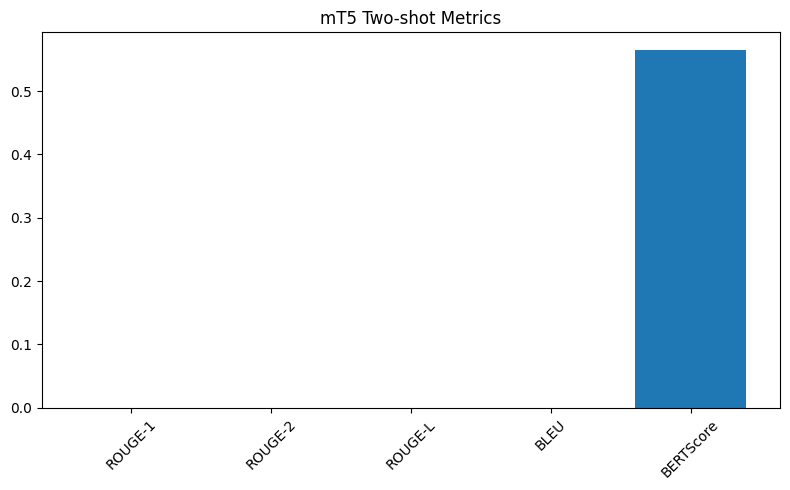

In [ ]:
metrics = compute_metrics(predictions, references)

print(metrics)

save_outputs(
    MT5_DIR,
    predictions,
    references,
    articles,
    metrics
)

plot_metrics(metrics, MT5_DIR, "mT5 Two-shot Metrics")

In [ ]:
from tqdm import tqdm
import pandas as pd
import torch

articles = []
references = []
predictions = []

for _, row in tqdm(val_df.iterrows(), total=len(val_df)):

    article = row["article"]
    reference = row["summary"]

    prompt = build_prompt(article)

    inputs = mbart_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        output = mbart_model.generate(
            **inputs,
            forced_bos_token_id=mbart_tokenizer.lang_code_to_id["ml_IN"],
            max_new_tokens=20,
            min_new_tokens=5,
            num_beams=5,
            do_sample=False,
            repetition_penalty=2.5,
            no_repeat_ngram_size=4,
            length_penalty=0.3,
            early_stopping=True
        )

    pred = mbart_tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    for bad in ["ലേഖനം:", "സംഗ്രഹം:"]:
        pred = pred.replace(bad, "")

    pred = pred.strip()

    articles.append(article)
    references.append(reference)
    predictions.append(pred)

100%|██████████| 970/970 [07:43<00:00,  2.09it/s]


In [ ]:
results_df = pd.DataFrame({
    "Article": articles,
    "Reference": references,
    "Prediction": predictions
})

results_df.to_csv(
    f"{SAVE_DIR}/mbart_twoshot_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved predictions")

Saved predictions


In [ ]:
display(results_df.sample(10))

,Article,Reference,Prediction
56,ജോലികഴിഞ്ഞ് വൈകുന്നേരം അയാൾ വീട്ടിലേക്കുളള യാത...,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,ജോലികഴിഞ്ഞ് വൈകുന്നേരം അയാൾ വീട്ടിലേക്കുളള യാത...
731,എമ്മില് നിന്നു പുറത്താക്കപ്പെട്ട കെ. മനോജ്. തന...,ജോളി ചതിച്ചു'; ഒപ്പിട്ടത് വെള്ളക്കടലാസിൽ; തുറന...,കേരളത്തിൽ ശക്തമായ മഴ തുടരുന്നതിനാൽ വിദ്യാഭ്യാസ...
429,"ഗോതമ്പ്, ചോളം, നെല്ല്, കരിമ്പ്, പരുത്തി, പയർവർ...","ഗോതമ്പ്, ചോളം, നെല്ല്, കരിമ്പ്, പരുത്തി, പയർവർ...",കേരളത്തിൽ ശക്തമായ മഴ തുടരുന്നതിനാൽ വിദ്യാഭ്യാസ...
178,1954 ൽ ചൈനയുമായി അതിർത്തിത്തർക്കം ഉണ്ടായപ്പോൾ ...,1954 ൽ ഇന്ത്യ ചൈനയുമായി ഒപ്പിട്ട കരാറാണ് പഞ്ചശ...,പഞ്ചശീലതത്ത്വങ്ങൾ. ജവഹർലാൽ നെഹ്റുവും ചൈന
946,ന്യൂഡൽഹി : ഐഎന്എക്സ് മീഡിയ അഴിമതിക്കേസില് തീഹാ...,ഐഎന്എക്സ് മീഡിയ കേസ് ; കാർത്തി കിടന്ന അതേ ജയില...,ഐഎന്എക്സ് മീഡിയ അഴിമതിക്കേസില് തീഹാര് ജയിലിലെ ...
646,മുസ്ലീങ്ങൾക്കിടയിൽ ആധുനികവിദ്യാഭ്യാസത്തിന് പ്ര...,മുസ്ലീങ്ങൾക്കിടയിൽ ആധുനികവിദ്യാഭ്യാസത്തിന് പ്ര...,
447,ന്യൂഡൽഹി: ഡല്ഹി തിരഞ്ഞെടുപ്പ് ഫലത്തില് സവിശേഷ ...,ല് രാഷ്ട്ര നിര്മാണത്തിന് എഎപി; ബാനര് പാര്ട്ടി ...,
848,വയനാട്: മാനന്തവാടിയിലെ ആദിവാസി യുവതിയുടെ മരണം ...,ആദിവാസി യുവതിയുടെ മരണം കൊലപാതകമാണെന്ന് ആരോപണം;...,വയനാട്: മാനന്തവാടിയിലെ ആദിവാസി യുവതിയുടെ മരണം ...
739,തൃശൂർ : എറിയാട് പഞ്ചായത്തിലെ വിവിധസ്ഥലങ്ങളിൽ പ...,പേപ്പട്ടി ആക്രമണം: എറിയാട് പഞ്ചായത്തിൽ വളർത്തു...,വളർത്തുമൃഗങ്ങൾക്കും പ്രതിരോധ കുത്തിവെപ്പും നടത...
279,"തുഞ്ചത്തെഴുത്തച്ഛൻ - 17, 2011 രാഘവവാക്യം കേട്ട...",പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,"തുഞ്ചത്തെഴുത്തച്ഛൻ - 17, 2011 രാഘവവാക്യം"


In [ ]:
metrics = compute_metrics(predictions, references)
print(metrics)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


calculating scores...
computing bert embedding.


  0%|          | 0/23 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 5.23 seconds, 185.64 sentences/sec
{'ROUGE-1': np.float64(0.006529209621993126), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.006529209621993126), 'BLEU': 1.524800430576267, 'BERTScore': 0.5594848394393921}


In [ ]:
import json

with open(f"{SAVE_DIR}/mbart_twoshot_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics")

Saved metrics


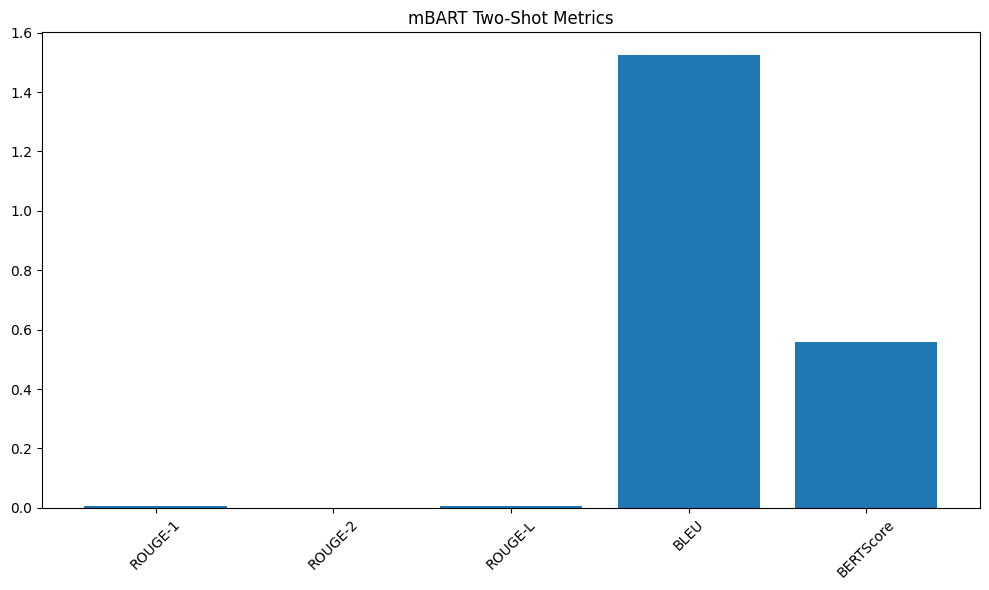

In [ ]:
import matplotlib.pyplot as plt

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

plt.figure(figsize=(10,6))
plt.bar(metric_names, metric_values)
plt.xticks(rotation=45)
plt.title("mBART Two-Shot Metrics")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/mbart_twoshot_metrics.png")
plt.show()